# NB03 — Market Entry Framework
**Project:** IMADATA Market Intelligence Framework — Mexico

**Research Objective 3:** Integrate opportunity and competition insights to identify regions where high-potential customer clusters coincide with low competitive saturation, providing a data-backed basis for market-entry sequencing.

**Inputs (from NB01 and NB02):**
- `outputs/state_opportunity_scores.csv` — customer opportunity score per state (0–1)
- `outputs/state_competitive_intensity.csv` — competitive intensity index per state (0–1)
- `outputs/municipality_hotspots.csv` — municipality-level competitor hotspot classifications
- `outputs/customer_segments.csv` — company-level cluster assignments

**Outputs produced:**
- `outputs/market_entry_matrix.csv` — opportunity vs competition score per state with quadrant classification
- `outputs/priority_markets.csv` — ranked Priority quadrant states with municipality drill-down

---
### Analytical framework

Each Mexican state is positioned in a 2×2 Market Opportunity Matrix:

```
                  LOW Competition     HIGH Competition
HIGH Opportunity │  PRIORITY          CONTESTED
                 │  Enter now         Enter with differentiation
─────────────────┼────────────────────────────────────
LOW  Opportunity │  MONITOR           AVOID
                 │  Watch for         Resource drain
                 │  market dev
```

> **On the low-competition assumption:** In knowledge-intensive B2B services, low competitor density can — in some markets — reflect low demand rather than open opportunity. In Mexico's context, where IMADATA serves as an *early entrant* into data analytics for SMEs, low competition more plausibly reflects underserved markets than absent demand. This assumption is acknowledged and should be revisited as market data matures.

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
import requests
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


In [2]:
OUT_DIR = Path('outputs')

# ── Matrix quadrant thresholds (median split — data-driven) ───────────────────
# Quadrant boundaries are set at the median of each axis so that roughly half
# of states fall on each side — avoiding arbitrary absolute cut-offs.
SPLIT_METHOD = 'median'   # 'median' | 'mean' | float (e.g. 0.5 for fixed midpoint)

# ── Entry score competition weight ────────────────────────────────────────────
# Formula: opportunity_score − COMPETITION_WEIGHT × competitive_intensity
# Set to 0.6: competition is penalised but not equally to opportunity.
# Rationale: some competitor presence validates market demand (blue-ocean
# markets with zero competition often signal low addressable demand rather
# than open opportunity). A weight < 1 reflects this; 0.6 was chosen as a
# midpoint between full penalty (1.0) and no penalty (0.0), calibrated so
# that a state must have meaningfully lower competitive intensity than its
# opportunity score to qualify as Priority. Adjust in sensitivity analysis.
COMPETITION_WEIGHT = 0.6

# ── Quadrant labels and recommended actions ───────────────────────────────────
QUADRANT_META = {
    'Priority'  : {'color': '#2ca02c', 'action': 'Enter now — high opportunity, low competition'},
    'Contested' : {'color': '#d62728', 'action': 'Enter with clear differentiation strategy'},
    'Monitor'   : {'color': '#ff7f0e', 'action': 'Watch for market development signals'},
    'Avoid'     : {'color': '#7f7f7f', 'action': 'Deprioritise — resource drain risk'},
}

print('Config set.')


Config set.


---
## 1 · Load & Align Inputs

In [3]:
opp_df  = pd.read_csv(OUT_DIR / 'state_opportunity_scores.csv')
comp_df = pd.read_csv(OUT_DIR / 'state_competitive_intensity.csv')
hotspot_df = pd.read_csv(OUT_DIR / 'municipality_hotspots.csv')
seg_df  = pd.read_csv(OUT_DIR / 'customer_segments.csv')

# ── Strip whitespace from state names (DENUE data artefact) ──────────────────
for df_ in [opp_df, comp_df]:
    df_['state_name'] = df_['state_name'].str.strip()

print(f'Opportunity scores      : {len(opp_df)} states')
print(f'Competitive intensity   : {len(comp_df)} states')
print(f'Municipality hotspots   : {len(hotspot_df):,} municipalities')
print(f'Customer segments       : {len(seg_df):,}')


Opportunity scores      : 32 states
Competitive intensity   : 32 states
Municipality hotspots   : 442 municipalities
Customer segments       : 43,330


In [4]:
# ── Merge on state_name ───────────────────────────────────────────────────────
matrix = opp_df[['state_name','total_companies','opportunity_score']].merge(
    comp_df[['state_name','density','competitive_intensity']],
    on='state_name',
    how='inner'
)

print(f'States in matrix: {len(matrix)}')
missing_opp  = set(opp_df['state_name'])  - set(matrix['state_name'])
missing_comp = set(comp_df['state_name']) - set(matrix['state_name'])
if missing_opp  : print(f'States in opportunity not in competition : {missing_opp}')
if missing_comp : print(f'States in competition not in opportunity : {missing_comp}')

matrix.head()

States in matrix: 32


,state_name,total_companies,opportunity_score,density,competitive_intensity
0,NUEVO LEON,1756,1.0000,1283,0.2812
1,BAJA CALIFORNIA,1037,0.9525,662,0.1249
2,BAJA CALIFORNIA SUR,302,0.8977,177,0.2048
3,AGUASCALIENTES,532,0.8943,317,0.2379
4,QUERETARO,802,0.8898,601,0.1030


---
## 2 · Quadrant Classification

In [5]:
# ── Determine split thresholds ────────────────────────────────────────────────
if SPLIT_METHOD == 'median':
    opp_threshold  = matrix['opportunity_score'].median()
    comp_threshold = matrix['competitive_intensity'].median()
elif SPLIT_METHOD == 'mean':
    opp_threshold  = matrix['opportunity_score'].mean()
    comp_threshold = matrix['competitive_intensity'].mean()
else:
    # Fixed value provided
    opp_threshold  = float(SPLIT_METHOD)
    comp_threshold = float(SPLIT_METHOD)

print(f'Opportunity split  (>{opp_threshold:.3f} = High)')
print(f'Competition split  (>{comp_threshold:.3f} = High)')


def assign_quadrant(row):
    high_opp  = row['opportunity_score']     >= opp_threshold
    high_comp = row['competitive_intensity'] >= comp_threshold
    if     high_opp and not high_comp: return 'Priority'
    if     high_opp and     high_comp: return 'Contested'
    if not high_opp and not high_comp: return 'Monitor'
    return 'Avoid'


matrix['quadrant'] = matrix.apply(assign_quadrant, axis=1)

print('\nQuadrant distribution:')
print(matrix['quadrant'].value_counts())

Opportunity split  (>0.403 = High)
Competition split  (>0.177 = High)

Quadrant distribution:
quadrant
Contested    8
Priority     8
Avoid        8
Monitor      8
Name: count, dtype: int64


---
## 3 · Market Opportunity Matrix

The core deliverable: every Mexican state plotted as a point in opportunity × competition space, coloured by strategic quadrant.

In [6]:
# ── Interactive Plotly scatter ────────────────────────────────────────────────
color_map = {q: QUADRANT_META[q]['color'] for q in QUADRANT_META}

fig = px.scatter(
    matrix,
    x='competitive_intensity',
    y='opportunity_score',
    color='quadrant',
    text='state_name',
    size='total_companies',
    size_max=40,
    title='Market Opportunity Matrix — Mexican States',
    labels={
        'competitive_intensity': 'Competitive Intensity Index (CII)',
        'opportunity_score'    : 'Customer Opportunity Score',
        'quadrant'             : 'Quadrant',
        'total_companies'      : 'Total Companies'
    },
    color_discrete_map=color_map,
    hover_data={'total_companies': True, 'density': True}
)

# Quadrant divider lines
fig.add_vline(x=comp_threshold, line_dash='dash', line_color='grey', line_width=1)
fig.add_hline(y=opp_threshold,  line_dash='dash', line_color='grey', line_width=1)

# Quadrant label annotations
x_lo = matrix['competitive_intensity'].min() * 0.95
x_hi = matrix['competitive_intensity'].max() * 1.0
y_lo = matrix['opportunity_score'].min() * 0.95
y_hi = matrix['opportunity_score'].max() * 1.0

annotations = [
    dict(x=x_lo, y=y_hi, text='PRIORITY\n↑ High Opp, Low Comp',
         showarrow=False, font=dict(color='#2ca02c', size=11), xanchor='left', yanchor='top'),
    dict(x=x_hi, y=y_hi, text='CONTESTED\n↑ High Opp, High Comp',
         showarrow=False, font=dict(color='#d62728', size=11), xanchor='right', yanchor='top'),
    dict(x=x_lo, y=y_lo, text='MONITOR\n↓ Low Opp, Low Comp',
         showarrow=False, font=dict(color='#ff7f0e', size=11), xanchor='left', yanchor='bottom'),
    dict(x=x_hi, y=y_lo, text='AVOID\n↓ Low Opp, High Comp',
         showarrow=False, font=dict(color='#7f7f7f', size=11), xanchor='right', yanchor='bottom'),
]
fig.update_layout(annotations=annotations)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=620, legend_title_text='Quadrant')
fig.show()

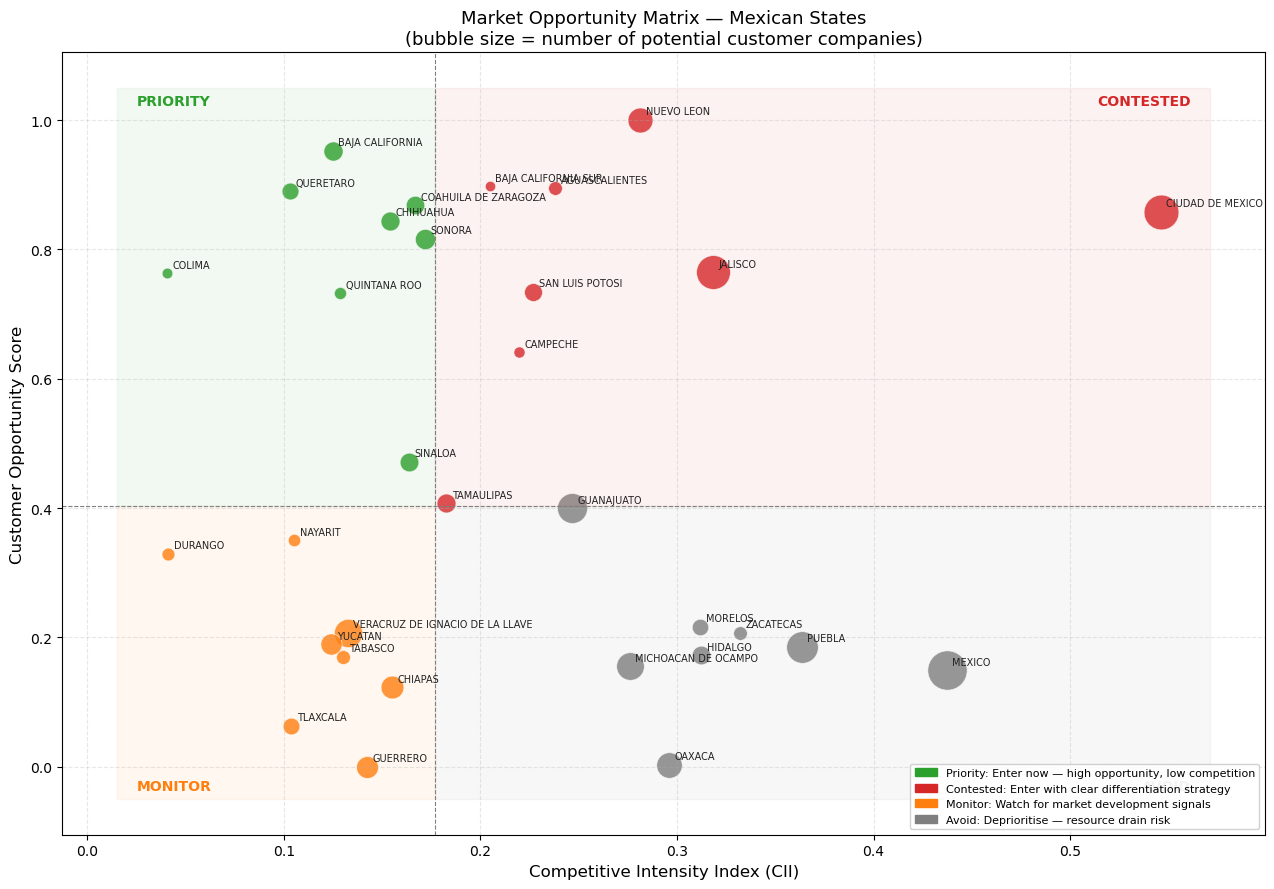

Chart saved to outputs/market_opportunity_matrix.png


In [7]:
# ── Static matplotlib version (for report/dissertation embedding) ─────────────
fig, ax = plt.subplots(figsize=(13, 9))

for _, row in matrix.iterrows():
    color = color_map[row['quadrant']]
    size  = max(30, row['total_companies'] / matrix['total_companies'].max() * 800)
    ax.scatter(row['competitive_intensity'], row['opportunity_score'],
               s=size, color=color, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.annotate(
        row['state_name'],
        xy=(row['competitive_intensity'], row['opportunity_score']),
        xytext=(4, 4), textcoords='offset points',
        fontsize=7, color='#222222'
    )

# Divider lines
ax.axvline(comp_threshold, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(opp_threshold,  color='grey', linestyle='--', linewidth=0.8)

# Quadrant shading
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.fill_betweenx([opp_threshold, ylim[1]], xlim[0], comp_threshold,
                  color='#2ca02c', alpha=0.06)  # Priority
ax.fill_betweenx([opp_threshold, ylim[1]], comp_threshold, xlim[1],
                  color='#d62728', alpha=0.06)  # Contested
ax.fill_betweenx([ylim[0], opp_threshold], xlim[0], comp_threshold,
                  color='#ff7f0e', alpha=0.06)  # Monitor
ax.fill_betweenx([ylim[0], opp_threshold], comp_threshold, xlim[1],
                  color='#7f7f7f', alpha=0.06)  # Avoid

# Quadrant labels
ax.text(xlim[0] + 0.01, ylim[1] - 0.01, 'PRIORITY',  color='#2ca02c', fontsize=10, fontweight='bold', va='top')
ax.text(xlim[1] - 0.01, ylim[1] - 0.01, 'CONTESTED', color='#d62728', fontsize=10, fontweight='bold', va='top',  ha='right')
ax.text(xlim[0] + 0.01, ylim[0] + 0.01, 'MONITOR',   color='#ff7f0e', fontsize=10, fontweight='bold', va='bottom')
ax.text(xlim[1] - 0.01, ylim[0] + 0.01, 'AVOID',     color='#7f7f7f', fontsize=10, fontweight='bold', va='bottom', ha='right')

# Legend
handles = [mpatches.Patch(color=QUADRANT_META[q]['color'], label=f"{q}: {QUADRANT_META[q]['action']}")
           for q in QUADRANT_META]
ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_xlabel('Competitive Intensity Index (CII)', fontsize=12)
ax.set_ylabel('Customer Opportunity Score', fontsize=12)
ax.set_title('Market Opportunity Matrix — Mexican States\n(bubble size = number of potential customer companies)',
             fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'market_opportunity_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/market_opportunity_matrix.png')

---
## 4 · Market Entry Sequencing

Priority states are ranked by a composite entry score that balances **tier quality** (proportion of high-tier firms, from NB01) with **total addressable volume** (number of firms in the state), penalised by competitive intensity.

**Why both quality and volume?**
A state where 90% of companies are Tier 1 but contains only 50 companies is less commercially attractive than a state where 60% are Tier 1 but contains 2,000 companies. The entry score prevents the framework from systematically favouring small, high-density-of-quality states over large markets with moderate quality.

**Formula:**
```
quality_volume = 0.7 × opportunity_score + 0.3 × volume_norm
entry_score    = quality_volume − 0.6 × competitive_intensity
```
- `opportunity_score` — tier-composition quality (NB01)
- `volume_norm` — normalised log(total_companies), dampened to reduce CDMX dominance
- `competitive_intensity` — CII composite (NB02)


In [8]:
# ── Entry score: quality × volume, penalised by competition ──────────────────
# Two dimensions of opportunity must be balanced:
#   (1) QUALITY  — tier composition: what proportion of companies are high-tier?
#                  Captured by opportunity_score (0–1, from NB01)
#   (2) VOLUME   — total addressable market: how many companies are there?
#                  A high-quality but tiny market (e.g. 50 companies) is less
#                  commercially attractive than a moderate-quality large market.
#
# These are combined as a volume-quality composite before penalising competition.
# log1p(n) is used for volume to dampen the outsized influence of very large
# states (e.g. CDMX with 3,416 companies vs Colima with 322).
#
# Final formula:
#   entry_score = (α × quality + (1-α) × volume_norm) − β × competition
#   α = QUALITY_WEIGHT = 0.7  (quality weighted more: IMADATA targets reachable firms)
#   β = COMPETITION_WEIGHT = 0.6  (set in config)

QUALITY_WEIGHT = 0.7   # weight on tier-quality score vs volume score

# Normalise log-volume to 0–1
import numpy as np
log_vol = np.log1p(matrix['total_companies'])
lo_v, hi_v = log_vol.min(), log_vol.max()
matrix['volume_norm'] = ((log_vol - lo_v) / (hi_v - lo_v)).round(4)

# Volume-quality composite
matrix['quality_volume_score'] = (
    QUALITY_WEIGHT * matrix['opportunity_score'] +
    (1 - QUALITY_WEIGHT) * matrix['volume_norm']
).round(4)

# Entry score: composite minus competition penalty
matrix['entry_score'] = (
    matrix['quality_volume_score'] -
    COMPETITION_WEIGHT * matrix['competitive_intensity']
).round(4)

# Normalise to 0–1
lo, hi = matrix['entry_score'].min(), matrix['entry_score'].max()
matrix['entry_score_norm'] = ((matrix['entry_score'] - lo) / (hi - lo)).round(4)

matrix['entry_rank'] = matrix['entry_score_norm'].rank(ascending=False).astype(int)
matrix = matrix.sort_values('entry_rank')

print('Top 15 states by entry score (quality + volume − competition):')
display(
    matrix[['entry_rank','state_name','quadrant','opportunity_score',
             'volume_norm','quality_volume_score',
             'competitive_intensity','entry_score_norm','total_companies']]
      .head(15)
      .reset_index(drop=True)
)
print()
print('Note: volume_norm = normalised log(total_companies). Shows both quality and market size.')


Top 15 states by entry score (quality + volume − competition):


,entry_rank,state_name,quadrant,opportunity_score,volume_norm,quality_volume_score,competitive_intensity,entry_score_norm,total_companies
0,1,BAJA CALIFORNIA,Priority,0.9525,0.4617,0.8053,0.1249,1.0000,1037
1,2,NUEVO LEON,Contested,1.0000,0.6590,0.8977,0.2812,0.9981,1756
2,3,QUERETARO,Priority,0.8898,0.3654,0.7325,0.1030,0.9173,802
3,4,COAHUILA DE ZARAGOZA,Priority,0.8681,0.4359,0.7384,0.1668,0.8725,968
4,5,CHIHUAHUA,Priority,0.8446,0.4544,0.7275,0.1538,0.8682,1017
5,6,SONORA,Priority,0.8163,0.4998,0.7213,0.1716,0.8448,1148
6,7,JALISCO,Contested,0.7646,0.8871,0.8014,0.3183,0.8338,3227
7,8,AGUASCALIENTES,Contested,0.8943,0.2118,0.6896,0.2379,0.7459,532
8,9,CIUDAD DE MEXICO,Contested,0.8580,0.9084,0.8731,0.5460,0.7440,3416
9,10,COLIMA,Priority,0.7628,0.0240,0.5412,0.0405,0.7044,322



Note: volume_norm = normalised log(total_companies). Shows both quality and market size.


In [9]:
# ── Priority quadrant states — detailed table ─────────────────────────────────
priority = matrix[matrix['quadrant'] == 'Priority'].copy()

print(f'Priority states ({len(priority)}):')
display(
    priority[['entry_rank','state_name','opportunity_score',
               'competitive_intensity','total_companies']]
      .reset_index(drop=True)
      .style
      .background_gradient(subset=['opportunity_score'], cmap='Greens')
      .background_gradient(subset=['competitive_intensity'], cmap='Reds_r')
      .format({'opportunity_score': '{:.3f}',
                'competitive_intensity': '{:.3f}',
                'total_companies': '{:,}'})
)

Priority states (8):


,entry_rank,state_name,opportunity_score,competitive_intensity,total_companies
0,1,BAJA CALIFORNIA,0.953,0.125,"1,037"
1,3,QUERETARO,0.890,0.103,802
2,4,COAHUILA DE ZARAGOZA,0.868,0.167,968
3,5,CHIHUAHUA,0.845,0.154,"1,017"
4,6,SONORA,0.816,0.172,"1,148"
5,10,COLIMA,0.763,0.041,322
6,13,QUINTANA ROO,0.732,0.129,414
7,15,SINALOA,0.472,0.164,989


In [10]:
fig = px.bar(
    matrix.head(20),
    x='entry_score_norm', y='state_name',
    orientation='h',
    color='quadrant',
    color_discrete_map=color_map,
    title='Market Entry Ranking — Top 20 States (normalised entry score)',
    labels={
        'entry_score_norm': 'Entry Score (0–1)',
        'state_name'      : 'State',
        'quadrant'        : 'Quadrant'
    }
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600
)
fig.show()

---
## 5 · Municipality Drill-Down for Priority States

For each Priority state: identify municipalities with the highest customer density but lowest competitor presence — these are the optimal first-contact locations.

In [11]:
# Load cleaned customers to get municipality-level customer counts
customers = pd.read_csv(OUT_DIR / 'cleaned_customers.csv', low_memory=False)

priority_states = priority['state_name'].tolist()

# Customer count per municipality in priority states
cust_muni = (
    customers[customers['state_name'].isin(priority_states)]
      .groupby(['state_name','municipality_name'])
      .size()
      .reset_index(name='customer_count')
)

# Competitor count per municipality (all types)
comp_muni = (
    pd.read_csv(OUT_DIR / 'competitors_filtered.csv', low_memory=False)
      [lambda x: x['state_name'].isin(priority_states)]
      .groupby(['state_name','municipality_name'])
      .size()
      .reset_index(name='competitor_count')
)

# Merge
drill = cust_muni.merge(comp_muni, on=['state_name','municipality_name'], how='left')
drill['competitor_count'] = drill['competitor_count'].fillna(0).astype(int)

# Compute municipality-level opportunity ratio
# Higher = more customers relative to competitors
drill['opportunity_ratio'] = (
    drill['customer_count'] / (drill['competitor_count'] + 1)  # +1 avoids division by zero
).round(2)

drill = drill.sort_values(['state_name','opportunity_ratio'], ascending=[True, False])

print('Top municipalities per priority state (highest customer/competitor ratio):')
display(
    drill.groupby('state_name').head(3)
         .reset_index(drop=True)
)

Top municipalities per priority state (highest customer/competitor ratio):


,state_name,municipality_name,customer_count,competitor_count,opportunity_ratio
0,BAJA CALIFORNIA,TECATE,35,7,4.3800
1,BAJA CALIFORNIA,PLAYAS DE ROSARITO,45,10,4.0900
2,BAJA CALIFORNIA,ENSENADA,188,98,1.9000
3,CHIHUAHUA,BOCOYNA,13,0,13.0000
4,CHIHUAHUA,OJINAGA,16,1,8.0000
5,CHIHUAHUA,BUENAVENTURA,5,0,5.0000
6,COAHUILA DE ZARAGOZA,SAN BUENAVENTURA,9,0,9.0000
7,COAHUILA DE ZARAGOZA,SABINAS,21,2,7.0000
8,COAHUILA DE ZARAGOZA,GENERAL CEPEDA,5,0,5.0000
9,COLIMA,TECOMAN,46,4,9.2000


In [12]:
# Visualise top 3 municipalities per priority state
top_munis = drill.groupby('state_name').head(3).copy()
top_munis['label'] = top_munis['municipality_name'] + '\n(' + top_munis['state_name'] + ')'

fig = px.scatter(
    top_munis,
    x='competitor_count',
    y='customer_count',
    color='state_name',
    size='opportunity_ratio',
    text='municipality_name',
    size_max=30,
    title='Priority State Municipalities — Customer Count vs Competitor Count\n(bubble size = opportunity ratio)',
    labels={
        'competitor_count': 'Competitor Count',
        'customer_count'  : 'Potential Customer Count',
        'state_name'      : 'State'
    }
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(height=560)
fig.show()

---
## 6 · Competitive Pressure Choropleth

State-level opportunity scores and competitive intensity visualised on Mexico maps side-by-side.

In [13]:
GEOJSON_URL = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

try:
    resp    = requests.get(GEOJSON_URL, timeout=10)
    mex_geo = resp.json()

    # Load geo lookup to get state_code for matching
    geo = pd.read_csv('General_state_muncipality.csv')
    geo.columns = geo.columns.str.strip().str.lower().str.replace(' ', '_')
    state_codes = geo.drop_duplicates('state_code')[['state_code','state_name']]

    matrix_geo = matrix.merge(state_codes, on='state_name', how='left')

    # ── Opportunity score choropleth ──────────────────────────────────────────
    fig1 = px.choropleth(
        matrix_geo,
        geojson=mex_geo,
        locations='state_code',
        color='opportunity_score',
        color_continuous_scale='Greens',
        title='Customer Opportunity Score by State',
        labels={'opportunity_score': 'Opportunity Score'},
        hover_name='state_name',
        hover_data={'quadrant': True, 'total_companies': True}
    )
    fig1.update_geos(fitbounds='locations', visible=False)
    fig1.update_layout(height=480)
    fig1.show()

    # ── Competitive intensity choropleth ──────────────────────────────────────
    fig2 = px.choropleth(
        matrix_geo,
        geojson=mex_geo,
        locations='state_code',
        color='competitive_intensity',
        color_continuous_scale='Reds',
        title='Competitive Intensity Index by State',
        labels={'competitive_intensity': 'CII'},
        hover_name='state_name',
        hover_data={'quadrant': True, 'density': True}
    )
    fig2.update_geos(fitbounds='locations', visible=False)
    fig2.update_layout(height=480)
    fig2.show()

except Exception as e:
    print(f'Choropleths skipped (network unavailable or GeoJSON mismatch): {e}')
    print('Bar charts in previous cells convey the same information.')

---
## 7 · Strategic Recommendations

Recommendations are grounded directly in the quadrant classification and entry ranking above. Each quadrant has a distinct strategic implication for IMADATA's market entry.

In [14]:
# ── Summary table by quadrant ─────────────────────────────────────────────────
quad_summary = (
    matrix.groupby('quadrant')
          .agg(
              n_states           =('state_name',          'count'),
              total_customers    =('total_companies',      'sum'),
              avg_opportunity    =('opportunity_score',    'mean'),
              avg_competition    =('competitive_intensity','mean'),
              avg_entry_score    =('entry_score_norm',     'mean')
          )
          .reset_index()
          .sort_values('avg_entry_score', ascending=False)
)

print('Quadrant summary:')
display(quad_summary)

Quadrant summary:


,quadrant,n_states,total_customers,avg_opportunity,avg_competition,avg_entry_score
3,Priority,8,6697,0.7923,0.1316,0.7927
1,Contested,8,11498,0.7746,0.2772,0.6953
2,Monitor,8,8566,0.1791,0.1168,0.2374
0,Avoid,8,15973,0.1861,0.3219,0.1632


In [15]:
# ── Print strategic recommendations ──────────────────────────────────────────
priority_names  = matrix[matrix['quadrant']=='Priority' ]['state_name'].str.strip().tolist()
contested_names = matrix[matrix['quadrant']=='Contested']['state_name'].str.strip().tolist()
monitor_names   = matrix[matrix['quadrant']=='Monitor'  ]['state_name'].str.strip().tolist()
avoid_names     = matrix[matrix['quadrant']=='Avoid'    ]['state_name'].str.strip().tolist()

top5 = matrix.head(5)['state_name'].str.strip().tolist()

# Load segment info dynamically from NB01 outputs
try:
    seg_info = pd.read_csv(OUT_DIR / 'customer_segments.csv')
    top_segments = seg_info['segment'].value_counts().head(2).index.tolist()
    seg_note = f"Focus on {top_segments[0]} and {top_segments[1]} — the highest-concentration segments in NB01."
except Exception:
    seg_note = "Refer to NB01 customer segment profiles to identify priority outreach tiers."

print('=' * 70)
print('STRATEGIC MARKET ENTRY RECOMMENDATIONS — IMADATA MEXICO')
print('=' * 70)

print(f'''
PRIORITY MARKETS — Enter Now
States: {', '.join(priority_names)}
These states combine high concentrations of digitally accessible wholesale
firms with below-median competitor saturation. IMADATA should prioritise
outbound sales activity here.
{seg_note}

Top 5 ranked states for immediate entry (entry score): {', '.join(top5)}

---
CONTESTED MARKETS — Differentiate Before Entering
States: {', '.join(contested_names)}
High customer opportunity exists but so does meaningful competitor presence.
Entry is viable but requires a clear differentiation narrative — likely
IMADATA's sector-specific data products and Spanish-language tooling.
Avoid competing on price in these states.

---
MONITOR MARKETS — Watch and Re-evaluate
States: {', '.join(monitor_names)}
Low competition but also low customer density currently. These may
represent nascent markets. Re-evaluate with the next DENUE release
(track CAGR in NB02) before committing resources.

---
AVOID (NEAR-TERM) — Deprioritise
States: {', '.join(avoid_names)}
High competition with low customer concentration. Resource investment
in these markets is unlikely to yield proportionate returns in the
short to medium term.
''')
print('=' * 70)


STRATEGIC MARKET ENTRY RECOMMENDATIONS — IMADATA MEXICO

PRIORITY MARKETS — Enter Now
States: BAJA CALIFORNIA, QUERETARO, COAHUILA DE ZARAGOZA, CHIHUAHUA, SONORA, COLIMA, QUINTANA ROO, SINALOA
These states combine high concentrations of digitally accessible wholesale
firms with below-median competitor saturation. IMADATA should prioritise
outbound sales activity here.
Focus on Tier 6 — Micro, Offline and Tier 4 — Micro, Phone-Reachable — the highest-concentration segments in NB01.

Top 5 ranked states for immediate entry (entry score): BAJA CALIFORNIA, NUEVO LEON, QUERETARO, COAHUILA DE ZARAGOZA, CHIHUAHUA

---
CONTESTED MARKETS — Differentiate Before Entering
States: NUEVO LEON, JALISCO, AGUASCALIENTES, CIUDAD DE MEXICO, BAJA CALIFORNIA SUR, SAN LUIS POTOSI, CAMPECHE, TAMAULIPAS
High customer opportunity exists but so does meaningful competitor presence.
Entry is viable but requires a clear differentiation narrative — likely
IMADATA's sector-specific data products and Spanish-language

---
## 8 · Export Outputs

In [16]:
# ── Full matrix with quadrant and entry scores ────────────────────────────────
matrix.to_csv(OUT_DIR / 'market_entry_matrix.csv', index=False)

# ── Priority markets with municipality drill-down ─────────────────────────────
priority_export = matrix[matrix['quadrant'] == 'Priority'].merge(
    drill.groupby('state_name').head(5),
    on='state_name', how='left'
)
priority_export.to_csv(OUT_DIR / 'priority_markets.csv', index=False)

print('Outputs saved to outputs/')
print(f'  market_entry_matrix.csv    —  {len(matrix)} states')
print(f'  priority_markets.csv       —  {len(priority)} priority states × top municipalities')
print(f'  market_opportunity_matrix.png  —  static chart for dissertation')

Outputs saved to outputs/
  market_entry_matrix.csv    —  32 states
  priority_markets.csv       —  8 priority states × top municipalities
  market_opportunity_matrix.png  —  static chart for dissertation
